# Avaliação de Modelos — Compatibilidade Adotante × Pet

Compara os 4 modelos candidatos (Decision Tree, Random Forest, Logistic
Regression, KNN) e detalha a avaliação do modelo selecionado no conjunto de
teste (holdout).

Pré-requisito: rode `python -m src.training.train` (gera os relatórios em
`artfacts/reports/` e o modelo em `models/animal-recommender/`).

Kernel: selecione **Abrigo Lambeijos ML**.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.config.settings import EVALUATION_REPORT_PATH, METRICS_PATH, MODEL_METADATA_PATH

with open(EVALUATION_REPORT_PATH, encoding="utf-8") as f:
    evaluation_report = json.load(f)
with open(METRICS_PATH, encoding="utf-8") as f:
    test_metrics = json.load(f)
with open(MODEL_METADATA_PATH, encoding="utf-8") as f:
    metadata = json.load(f)

print(f"Modelo selecionado: {evaluation_report['selected_model']}")

Modelo selecionado: random_forest


## Comparação dos candidatos (validação cruzada, F1)

In [2]:
candidates = evaluation_report["candidates"]
comparison = pd.DataFrame(
    {name: {"f1_mean": r["f1_mean"], "f1_std": r["f1_std"]} for name, r in candidates.items()}
).T.sort_values("f1_mean", ascending=False)
comparison

,f1_mean,f1_std
random_forest,0.812329,0.031284
logistic_regression,0.774732,0.029611
knn,0.759649,0.027523
decision_tree,0.738206,0.011829


## Modelo selecionado — avaliação no conjunto de teste (holdout)

Treinado em: 2026-09-24T19:12:03.778036+00:00
Tamanho treino/teste: 600 / 150
F1 (CV): 0.812
Teste: accuracy=0.793, precision=0.802, recall=0.831, f1=0.817


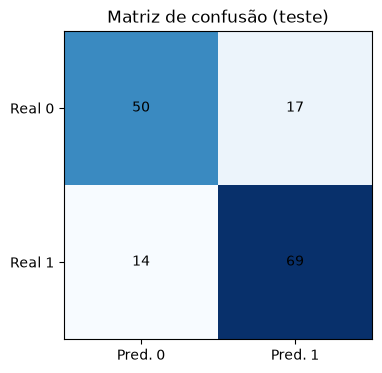

In [3]:
import matplotlib.pyplot as plt
import numpy as np

print(f"Treinado em: {metadata['trained_at']}")
print(f"Tamanho treino/teste: {metadata['train_size']} / {metadata['test_size']}")
print(f"F1 (CV): {metadata['cv_f1_mean']:.3f}")
print(
    f"Teste: accuracy={test_metrics['accuracy']:.3f}, precision={test_metrics['precision']:.3f}, "
    f"recall={test_metrics['recall']:.3f}, f1={test_metrics['f1']:.3f}"
)

cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_xticks([0, 1], labels=["Pred. 0", "Pred. 1"])
ax.set_yticks([0, 1], labels=["Real 0", "Real 1"])
ax.set_title("Matriz de confusão (teste)")
plt.show()